# EDA - Right Home

### Notera: Koden och datan har uppdaterats, samt EDA:n.

## 1. Imports & Setup

In [19]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

GRAY_1 = "#aaaaaa"
GRAY_2 = "#888888"
GRAY_3 = "#444444"
HIGHLIGHT = "#E07B54"
BASE_COLOR = "#bbbbbb"

## 2. Data med DuckDB

In [20]:
df_bostader  = pd.read_csv('../ETL_Pipline/bostader.csv')
df_priser    = pd.read_csv('../ETL_Pipline/priser.csv')
df_platser   = pd.read_csv('../ETL_Pipline/platser.csv')
df_visningar = pd.read_csv('../ETL_Pipline/visningar.csv')

con = duckdb.connect()
con.register('bostader',  df_bostader)
con.register('priser',    df_priser)
con.register('platser',   df_platser)
con.register('visningar', df_visningar)

print('Tabeller inlasta:')
print(f'  bostader:  {len(df_bostader)} rader')
print(f'  priser:    {len(df_priser)} rader')
print(f'  platser:   {len(df_platser)} rader')
print(f'  visningar: {len(df_visningar)} rader')

Tabeller inlasta:
  bostader:  1000 rader
  priser:    1000 rader
  platser:   20 rader
  visningar: 2 rader


## 3. Joina tabeller med hjälp av DuckDB

In [21]:
query = """
    SELECT *
    FROM bostader b
    JOIN priser    p  ON b.id       = p.bostad_id
    JOIN platser   pl ON b.plats_id = pl.plats_id
"""

df = con.execute(query).df()
df['created_at'] = pd.to_datetime(df['created_at'])
print(f'Sammanfogad tabell: {df.shape[0]} rader, {df.shape[1]} kolumner')
df.head()

Sammanfogad tabell: 1000 rader, 30 kolumner


,id,typ,upplåtelseform,rum,boyta,boyta_enhet,tillgänglig,created_at,adress,lat,...,bostad_id,pris,avgift,kvadratmeterpris,pris_per_kvm,valuta,område,stad,plats_id_1,kommun_befolkning
0,1,hus,köpa,4,108,m²,True,2025-08-29,Drottninggatan 28,59.33820,...,1,11411993,4177,105666,105667.0,SEK,Bromma,Stockholm,1,995574
1,2,hus,köpa,6,138,m²,True,2026-03-18,Skolvägen 104,55.58171,...,2,6959222,2820,50429,50429.0,SEK,Rosengård,Malmö,2,365644
2,3,lägenhet,hyra,3,75,m²,True,2025-09-22,Drottninggatan 90,55.60470,...,3,10345,0,0,138.0,SEK,Västra Hamnen,Malmö,3,365644
3,4,lägenhet,köpa,3,69,m²,True,2026-01-01,Kyrkogatan 33,57.69446,...,4,3484199,3983,50495,50496.0,SEK,Linnéstaden,Göteborg,4,608993
4,5,lägenhet,hyra,2,42,m²,False,2025-09-14,Hornsgatan 94,55.58295,...,5,7077,0,0,168.0,SEK,Limhamn,Malmö,5,365644


## 4. Datakvalitet - Kvalitetskontroll

In [22]:
print('=== Datatyper & null-värden ===')
print(df.info())

=== Datatyper & null-värden ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     1000 non-null   int64         
 1   typ                    1000 non-null   str           
 2   upplåtelseform         1000 non-null   str           
 3   rum                    1000 non-null   int64         
 4   boyta                  1000 non-null   int64         
 5   boyta_enhet            1000 non-null   str           
 6   tillgänglig            1000 non-null   bool          
 7   created_at             1000 non-null   datetime64[us]
 8   adress                 1000 non-null   str           
 9   lat                    1000 non-null   float64       
 10  lon                    1000 non-null   float64       
 11  plats_id               1000 non-null   int64         
 12  sparad                 1000 non-null   int

In [23]:
display(df[['pris', 'avgift', 'rum', 'boyta', 'pris_per_kvm']].describe().round(0))

,pris,avgift,rum,boyta,pris_per_kvm
count,1000.0,1000.0,1000.0,1000.0,1000.0
mean,4372299.0,2984.0,3.0,81.0,53728.0
std,4077370.0,2402.0,2.0,41.0,38147.0
min,2166.0,0.0,1.0,18.0,120.0
25%,1013853.0,1529.0,2.0,46.0,33472.0
50%,3604906.0,2840.0,4.0,80.0,50628.0
75%,6621601.0,4126.0,5.0,112.0,76932.0
max,21282713.0,12538.0,6.0,168.0,132518.0


In [24]:
print(f'Antal dubletter (på id): {df.duplicated(subset=["id"]).sum()}')
print(f'\nFördelning per stad:')
print(df['stad'].value_counts())
print(f'\nBostadstyper:')
print(df['typ'].value_counts())
print(f'\nUpplåtelseformer:')
print(df['upplåtelseform'].value_counts())

Antal dubletter (på id): 0

Fördelning per stad:
stad
Malmö        339
Stockholm    332
Göteborg     329
Name: count, dtype: int64

Bostadstyper:
typ
hus         503
lägenhet    497
Name: count, dtype: int64

Upplåtelseformer:
upplåtelseform
köpa    781
hyra    219
Name: count, dtype: int64


## 5. Outlier-analys - DuckDB

In [25]:
outliers = con.execute("""
    SELECT id, stad, område, boyta, pris, pris_per_kvm
    FROM df
    WHERE pris_per_kvm > 120000
       OR pris_per_kvm < 5000
       OR boyta < 20
    ORDER BY pris_per_kvm DESC
""").df()

print(f'Potentiella outliers: {len(outliers)} st')
display(outliers)

Potentiella outliers: 304 st


,id,stad,område,boyta,pris,pris_per_kvm
0,406,Stockholm,Farsta,80,10601463,132518.0
1,191,Stockholm,Vasastan,24,3180010,132500.0
2,54,Stockholm,Södermalm,120,15878757,132323.0
3,446,Stockholm,Spånga,100,13200508,132005.0
4,77,Stockholm,Bromma,125,16461124,131689.0
...,...,...,...,...,...,...
299,785,Göteborg,Linnéstaden,100,12109,121.0
300,166,Stockholm,Nacka,19,2282,120.0
301,481,Stockholm,Kungsholmen,42,5042,120.0
302,995,Stockholm,Kungsholmen,110,13237,120.0


In [26]:
df_clean = con.execute("""
    SELECT * FROM df
    WHERE pris_per_kvm BETWEEN 5000 AND 120000
    AND boyta >= 20
""").df()

städer_i_data = sorted(df_clean['stad'].unique())
print(f'Rader efter filtrering: {len(df_clean)} (borttagna: {len(df) - len(df_clean)})')
print(f'Städer i datan: {städer_i_data}')

Rader efter filtrering: 696 (borttagna: 304)
Städer i datan: ['Göteborg', 'Malmö', 'Stockholm']


## 6. Data Storytelling – Graf 1
### Varför kostar Stockholm dubbelt så mycket per kvadratmeter?

Grafen ska jämföra den genomsnittliga pris per kvm per stad. Frågan lyder så här — vad gör Stockholm annorlunda?

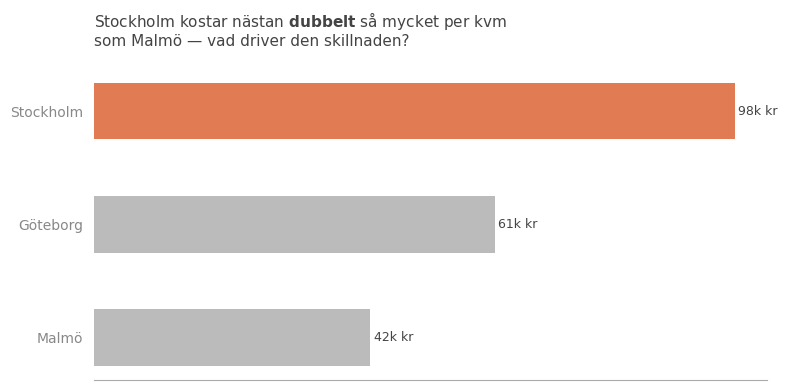

In [27]:
agg = (
    df_clean
    .groupby('stad')['pris_per_kvm']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

# Highlighta Stockholm, gråar ut resten
colors = [HIGHLIGHT if s == 'Stockholm' else BASE_COLOR for s in agg['stad']]

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(agg['stad'], agg['pris_per_kvm'] / 1000,
               color=colors, height=0.5)

# Värdelabels
for bar, val in zip(bars, agg['pris_per_kvm']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val/1000:.0f}k kr', va='center', fontsize=9, color=GRAY_3)

# Tar bort grid och spines
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRAY_1)
ax.xaxis.set_visible(False)

# Dämpar tick-labels
ax.tick_params(axis='y', colors=GRAY_2, labelsize=10, length=0, pad=8)

# Storytelling titel
ax.set_title(
    'Stockholm kostar nästan ' + r'$\bf{dubbelt}$' + ' så mycket per kvm\n'
    'som Malmö — vad driver den skillnaden?',
    loc='left', color=GRAY_3, fontsize=11, pad=16
)

fig.tight_layout()
plt.show()


## 7. Data Storytelling – Graf 2
### Stockholm-bostäder är dyra oavsett storlek

Boyta mot pris. Återigen highlightas Stockholm, medan övriga städer tonas ner. Detta är för att verkligen visa att Stockholm faktiskt håller i sig oavsett hur stor bostaden är.

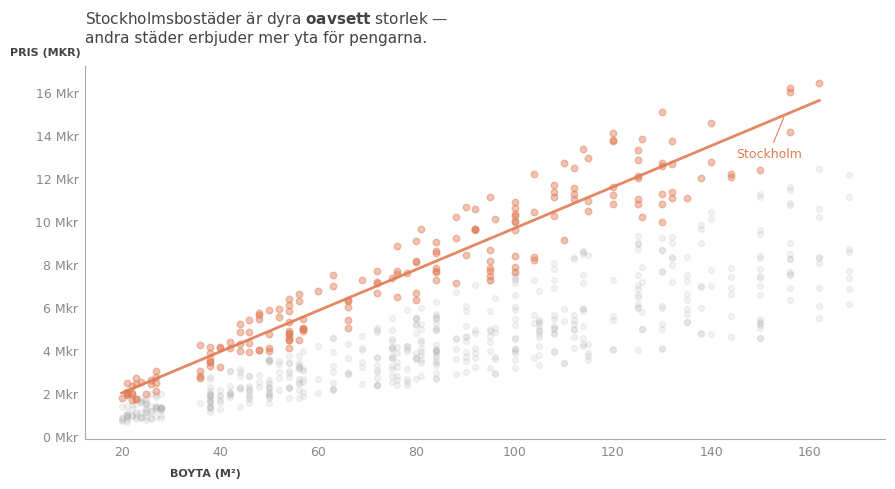

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

# Övriga städer först (grå, bakgrund)
for stad in städer_i_data:
    if stad == 'Stockholm':
        continue
    subset = df_clean[df_clean['stad'] == stad]
    ax.scatter(subset['boyta'], subset['pris'] / 1_000_000,
               alpha=0.15, s=18, color=GRAY_1)

# Stockholm highlightad ovanpå
sthlm = df_clean[df_clean['stad'] == 'Stockholm']
ax.scatter(sthlm['boyta'], sthlm['pris'] / 1_000_000,
           alpha=0.45, s=22, color=HIGHLIGHT, label='Stockholm')

# En trendlinje bara för Stockholm
z = sthlm[['boyta', 'pris']].dropna()
coef = np.polyfit(z['boyta'], z['pris'], 1)
xs = np.linspace(z['boyta'].min(), z['boyta'].max(), 100)
ax.plot(xs, np.polyval(coef, xs) / 1_000_000,
        color=HIGHLIGHT, linewidth=2, alpha=0.9)

# Tar bort legend, för annotation
ax.annotate('Stockholm', xy=(155, np.polyval(coef, 155) / 1_000_000),
            xytext=(145, 13), color=HIGHLIGHT, fontsize=9,
            arrowprops=dict(arrowstyle='-', color=HIGHLIGHT, lw=0.8))

# Spines
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRAY_1)
ax.tick_params(axis='both', colors=GRAY_2, labelsize=9, length=0, pad=5)

ax.set_xlabel('BOYTA (M²)', color=GRAY_3, fontsize=8, fontweight='bold')
ax.set_ylabel('PRIS (MKR)', color=GRAY_3, fontsize=8, fontweight='bold', rotation=0)
ax.yaxis.set_label_coords(-0.05, 1.02)
ax.xaxis.set_label_coords(0.15, -0.08)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f} Mkr'))

ax.set_title(
    'Stockholmsbostäder är dyra ' + r'$\bf{oavsett}$' + ' storlek —\n'
    'andra städer erbjuder mer yta för pengarna.',
    loc='left', color=GRAY_3, fontsize=11, pad=16
)

fig.tight_layout()
plt.show()


## 8. Data Storytelling – Graf 3
### Stabil prisnivå i Stockholm — i Malmö och Göteborg svänger det mer

Line chart med prisutveckling per månad.

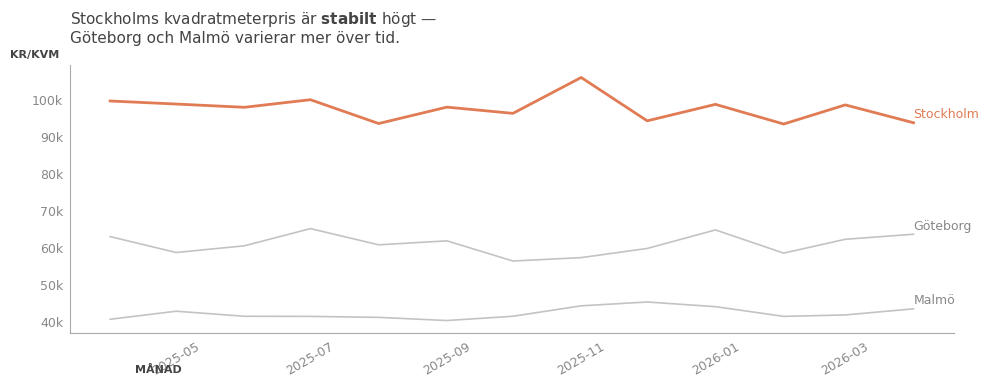

In [30]:
df_trend = df_clean.copy()
df_trend['created_at'] = pd.to_datetime(df_trend['created_at'])
df_trend['månad'] = df_trend['created_at'].dt.to_period('M')

trend = (
    df_trend
    .groupby(['månad', 'stad'])['pris_per_kvm']
    .mean()
    .reset_index()
)
trend['månad_dt'] = trend['månad'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))

for stad in städer_i_data:
    data = trend[trend['stad'] == stad].sort_values('månad_dt')
    if stad == 'Stockholm':
        ax.plot(data['månad_dt'], data['pris_per_kvm'] / 1000,
                linewidth=2, color=HIGHLIGHT, zorder=3)
        # Label direkt på linjen
        last = data.iloc[-1]
        ax.text(last['månad_dt'], last['pris_per_kvm'] / 1000 + 0.5,
                'Stockholm', color=HIGHLIGHT, fontsize=9, va='bottom')
    else:
        ax.plot(data['månad_dt'], data['pris_per_kvm'] / 1000,
                linewidth=1.2, color=GRAY_1, zorder=2, alpha=0.7)
        last = data.iloc[-1]
        ax.text(last['månad_dt'], last['pris_per_kvm'] / 1000 + 0.5,
                stad, color=GRAY_2, fontsize=9, va='bottom')

# Spines
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRAY_1)
ax.tick_params(axis='both', colors=GRAY_2, labelsize=9, length=0, pad=5)
plt.xticks(rotation=30)

ax.set_xlabel('MÅNAD', color=GRAY_3, fontsize=8, fontweight='bold')
ax.set_ylabel('KR/KVM', color=GRAY_3, fontsize=8, fontweight='bold', rotation=0)
ax.yaxis.set_label_coords(-0.04, 1.02)
ax.xaxis.set_label_coords(0.1, -0.12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k'))

ax.set_title(
    'Stockholms kvadratmeterpris är ' + r'$\bf{stabilt}$' + ' högt —\n'
    'Göteborg och Malmö varierar mer över tid.',
    loc='left', color=GRAY_3, fontsize=11, pad=16
)

fig.tight_layout()
plt.show()


## 9. Kort Graf Sammanfattning!

- Stockholm dominerar prismässigt, upp till ~2x högre kvadratmeterpris än Malmö.
- Stockholmspremiumen är riktig och håller i sig oavsett boytans storlek.
- Prisnivån i Stockholm är stabil över tid, medan Göteborg och Malmö svänger betydligt mer.